In [4]:
# =============================================================================
# AIR QUALITY UCI DATASET: ANALYSIS
# =============================================================================
# Models: Gradient Boosting, Extra Trees, AdaBoost
# 1. Dataset Loading & Preprocessing
# 2. Interesting & Easy EDA Visualizations
# 3. Comparative Evaluation & Rank Table
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier, ExtraTreesClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [5]:
# -----------------------------------------------------------------------------
# STEP 1: LOAD & CLEAN DATA
# -----------------------------------------------------------------------------
#from google.colab import files
#uploaded = files.upload()
df = pd.read_csv('AirQualityUCI.csv')

# Replace -200 with NaN
df.replace(-200, np.nan, inplace=True)

# Fill missing numerical values using median
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Dropping non-predictive or high-null columns as per original notebook
df_clean = df.drop(['Date', 'Time', 'NMHC_GT', 'CO_GT'], axis=1)

print(f"✓ Data Prepared. Features: {df_clean.shape[1]-1}, Records: {df_clean.shape[0]}")

✓ Data Prepared. Features: 11, Records: 9357


In [6]:
df.head()

,Date,Time,CO_GT,PT08_S1_CO,NMHC_GT,C6H6_GT,PT08_S2_NMHC,Nox_GT,PT08_S3_Nox,NO2_GT,PT08_S4_NO2,PT08_S5_O3,T,RH,AH,CO_level
0,11/23/2004,19:00:00,11.9,2008.0,150.0,50.6,1980.0,1389.0,325.0,220.0,2562.0,2342.0,12.4,74.7,1.0741,Very High
1,11/23/2004,20:00:00,11.5,1918.0,150.0,49.4,1958.0,1358.0,335.0,190.0,2477.0,2237.0,11.5,76.2,1.0324,Very High
2,11/17/2004,18:00:00,10.2,1802.0,150.0,47.7,1924.0,748.0,356.0,192.0,2235.0,2452.0,13.7,52.8,0.8244,Very High
3,11/23/2004,18:00:00,10.2,1982.0,150.0,49.5,1959.0,1369.0,322.0,227.0,2536.0,2386.0,13.2,72.6,1.0936,Very High
4,11/26/2004,18:00:00,10.1,1956.0,150.0,45.2,1877.0,1389.0,347.0,255.0,2338.0,2465.0,15.5,62.8,1.0979,Very High


In [7]:
df.tail()

,Date,Time,CO_GT,PT08_S1_CO,NMHC_GT,C6H6_GT,PT08_S2_NMHC,Nox_GT,PT08_S3_Nox,NO2_GT,PT08_S4_NO2,PT08_S5_O3,T,RH,AH,CO_level
9352,3/23/2005,4:00:00,1.8,993.0,150.0,2.3,604.0,85.0,848.0,65.0,1160.0,762.0,14.5,66.4,1.0919,Very low
9353,3/26/2005,4:00:00,1.8,1122.0,150.0,6.0,811.0,181.0,641.0,92.0,1336.0,1122.0,16.2,71.2,1.3013,Very low
9354,3/29/2005,4:00:00,1.8,883.0,150.0,1.3,530.0,63.0,997.0,46.0,1102.0,617.0,13.7,68.2,1.0611,Very low
9355,04/01/2005,4:00:00,1.8,818.0,150.0,0.8,473.0,47.0,1257.0,41.0,898.0,323.0,13.7,48.8,0.7606,Very low
9356,04/04/2005,4:00:00,1.8,864.0,150.0,0.8,478.0,52.0,1116.0,43.0,958.0,489.0,11.8,56.0,0.7743,Very low


In [8]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PT08_S1_CO    9357 non-null   float64
 1   C6H6_GT       9357 non-null   float64
 2   PT08_S2_NMHC  9357 non-null   float64
 3   Nox_GT        9357 non-null   float64
 4   PT08_S3_Nox   9357 non-null   float64
 5   NO2_GT        9357 non-null   float64
 6   PT08_S4_NO2   9357 non-null   float64
 7   PT08_S5_O3    9357 non-null   float64
 8   T             9357 non-null   float64
 9   RH            9357 non-null   float64
 10  AH            9357 non-null   float64
 11  CO_level      9357 non-null   object 
dtypes: float64(11), object(1)
memory usage: 877.3+ KB


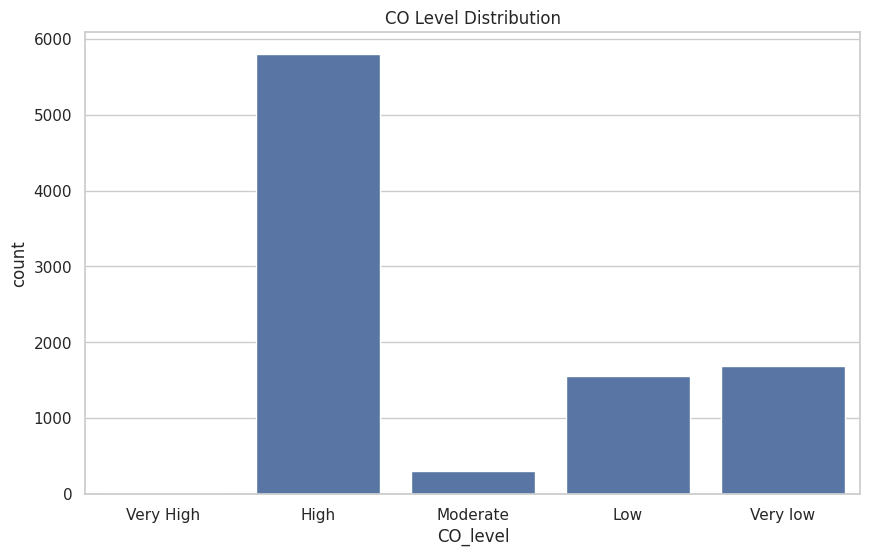

In [9]:
plt.figure()
sns.countplot(x='CO_level', data=df_clean)
plt.title('CO Level Distribution')
plt.show()

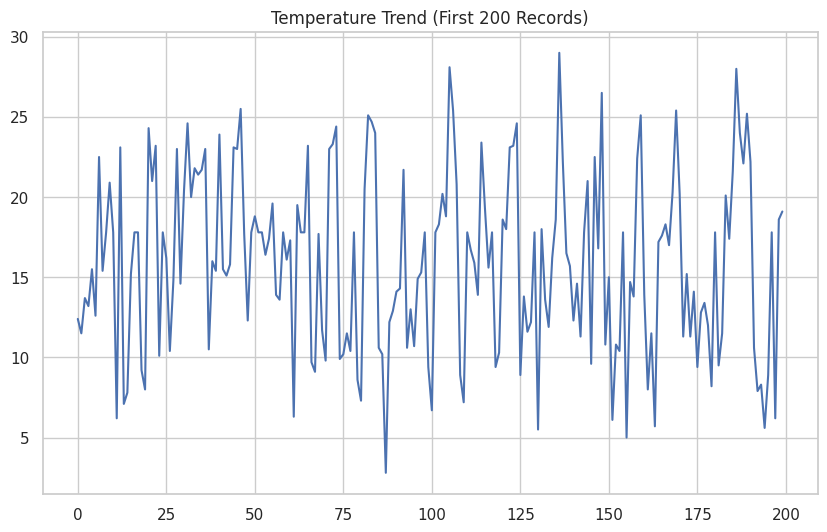

In [10]:
plt.figure()
df_clean['T'].head(200).plot()
plt.title('Temperature Trend (First 200 Records)')
plt.show()

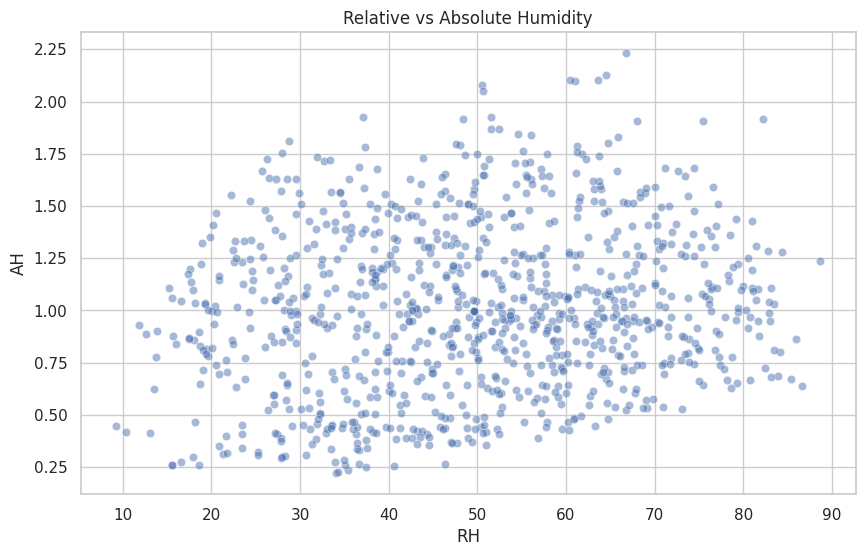

In [11]:
plt.figure()
sns.scatterplot(x='RH', y='AH', data=df_clean.sample(1000), alpha=0.5)
plt.title('Relative vs Absolute Humidity')
plt.show()


In [12]:
# -----------------------------------------------------------------------------
# STEP 3: PREPROCESSING
# -----------------------------------------------------------------------------
le = LabelEncoder()
df_clean['CO_level'] = le.fit_transform(df_clean['CO_level'].astype(str))

X = df_clean.drop('CO_level', axis=1)
y = df_clean['CO_level']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
# -----------------------------------------------------------------------------
# STEP 4: MODELS
# -----------------------------------------------------------------------------
results = []

models = {
    "Gradient Boosting": GradientBoostingClassifier(),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42)
}

print("\nTraining Models...")

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)

    results.append({
        "Algorithm": name,
        "Accuracy": round(accuracy_score(y_test, preds), 4),
        "Precision": round(precision_score(y_test, preds, average='weighted'), 4),
        "Recall": round(recall_score(y_test, preds, average='weighted'), 4),
        "F1-Score": round(f1_score(y_test, preds, average='weighted'), 4)
    })



Training Models...


In [14]:
# -----------------------------------------------------------------------------
# STEP 5: RANK TABLE
# -----------------------------------------------------------------------------
rank_table = pd.DataFrame(results).sort_values(
    by='F1-Score', ascending=False
).reset_index(drop=True)

rank_table.index += 1
rank_table.index.name = "Rank"

print("\n" + "="*70)
print("PERFORMANCE RANK TABLE")
print("="*70)
print(rank_table)


PERFORMANCE RANK TABLE
              Algorithm  Accuracy  Precision  Recall  F1-Score
Rank                                                          
1           Extra Trees    0.8510     0.8382  0.8510    0.8389
2     Gradient Boosting    0.8339     0.8157  0.8339    0.8206
3              AdaBoost    0.7869     0.7737  0.7869    0.7795


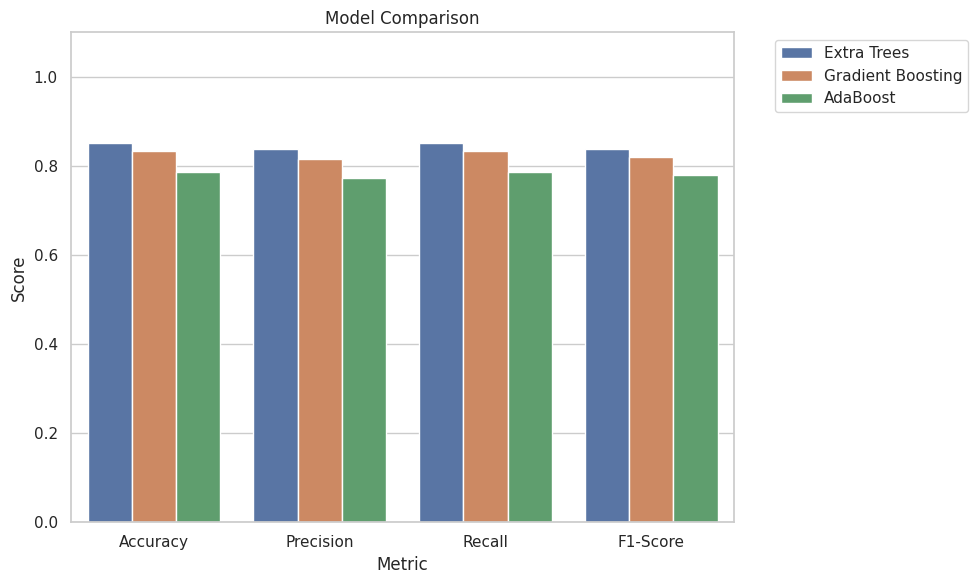

In [15]:
# Comparison Plot
plt.figure()
melted = rank_table.melt(id_vars='Algorithm', var_name='Metric', value_name='Score')

sns.barplot(x='Metric', y='Score', hue='Algorithm', data=melted)
plt.title('Model Comparison')
plt.ylim(0, 1.1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [16]:
# -----------------------------------------------------------------------------
# HYPERPARAMETER TUNING (GridSearchCV)
# -----------------------------------------------------------------------------

# Define Parameter Grids
param_grids = {
    'GradientBoosting': {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5]
    },
    'ExtraTrees': {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5]
    },
    'AdaBoost': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 1.0]
    }
}

# Initialize Models
models = {
    'GradientBoosting': GradientBoostingClassifier(random_state=42),
    'ExtraTrees': ExtraTreesClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42)
}

tuned_models = {}

# Execute Tuning and K-Fold Cross Validation
for name, model in models.items():
    print(f"Tuning {name}...")
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train_scaled, y_train)

    tuned_models[name] = grid.best_estimator_

    cv_scores = cross_val_score(grid.best_estimator_, X_train_scaled, y_train, cv=5)
    print(f"Best Params: {grid.best_params_}")
    print(f"Mean CV Accuracy: {cv_scores.mean():.4f}\n")

Tuning GradientBoosting...
Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Mean CV Accuracy: 0.8521

Tuning ExtraTrees...
Best Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Mean CV Accuracy: 0.8568

Tuning AdaBoost...
Best Params: {'learning_rate': 1.0, 'n_estimators': 50}
Mean CV Accuracy: 0.8064



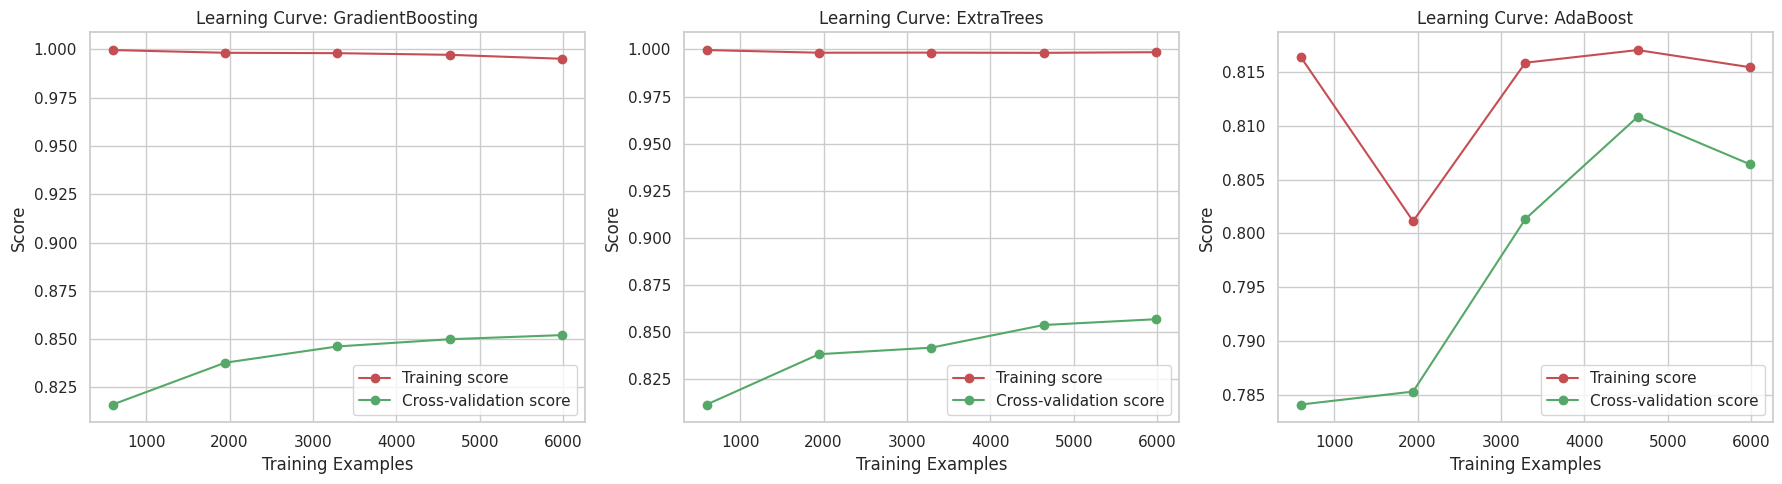

In [18]:
# -----------------------------------------------------------------------------
# LEARNING CURVES FOR ALL THREE MODELS
# -----------------------------------------------------------------------------

def plot_all_learning_curves(models_dict, X, y):
    plt.figure(figsize=(18, 5))

    for i, (name, model) in enumerate(models_dict.items()):
        plt.subplot(1, 3, i+1)
        train_sizes, train_scores, test_scores = learning_curve(
            model, X, y, cv=5, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5)
        )

        train_mean = np.mean(train_scores, axis=1)
        test_mean = np.mean(test_scores, axis=1)

        plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training score")
        plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-validation score")
        plt.title(f"Learning Curve: {name}")
        plt.xlabel("Training Examples")
        plt.ylabel("Score")
        plt.legend(loc="best")
        plt.grid(True)

    plt.tight_layout()
    plt.show()

# Generate the plots
plot_all_learning_curves(tuned_models, X_train_scaled, y_train)